# 複合スコア comp_ew × ens_lgbm_dnn（生 / EMA 平滑化）の評価

`scripts/build_blend.py` で作った複合スコア 2 系統を、親スコアと比較する。

- `comp_ew_{w}_ai_{100−w}`: `comp_ew` × `ens_lgbm_dnn`（生スコア）
- `comp_ew_{w}_ai_hl1_{100−w}`: `comp_ew` × `ens_lgbm_dnn_hl1`（EMA 平滑化、半減期 1 か月）

w = 90, 80, 70, 60, 50（comp_ew の重み %）。合成手順は各月ユニバース内で両者を Blom 正規スコアに変換 → 加重平均 → 再 Blom 化。

**規約**: 分位は **Q5 = スコア最上位**。リターンは `drtn`（配当込みトータル）と `srtn`（固有）。累積は drtn が複利、srtn が累和。
税は信託扱い・INR 建て、売買コスト 15/25bp、バーンイン 12 か月。ベンチマークは MSCI India。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, compute_alpha_report, india_tax_schedule, plot_cross_alpha_bars, plot_cumulative, summary_table

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

INPUT_ROOT = "../../input/msci_india_imi"
SCORES = {'comp_ew': 'composite/comp_ew', 'comp_ew_90_ai_10': 'blend/comp_ew_90_ai_10', 'comp_ew_80_ai_20': 'blend/comp_ew_80_ai_20', 'comp_ew_70_ai_30': 'blend/comp_ew_70_ai_30', 'comp_ew_60_ai_40': 'blend/comp_ew_60_ai_40', 'comp_ew_50_ai_50': 'blend/comp_ew_50_ai_50', 'ens_lgbm_dnn': 'my_ai/ens_lgbm_dnn', 'comp_ew_90_ai_hl1_10': 'blend_hl1/comp_ew_90_ai_hl1_10', 'comp_ew_80_ai_hl1_20': 'blend_hl1/comp_ew_80_ai_hl1_20', 'comp_ew_70_ai_hl1_30': 'blend_hl1/comp_ew_70_ai_hl1_30', 'comp_ew_60_ai_hl1_40': 'blend_hl1/comp_ew_60_ai_hl1_40', 'comp_ew_50_ai_hl1_50': 'blend_hl1/comp_ew_50_ai_hl1_50', 'ens_lgbm_dnn_hl1': 'my_ai/ens_lgbm_dnn_hl1'}
HIGHLIGHT = ['comp_ew', 'comp_ew_60_ai_40', 'comp_ew_60_ai_hl1_40']
BENCHMARK = "msci_india"
RISK_MODEL = "GEMLT"
RETURN_KINDS = {"drtn": "rtn", "srtn": "srtn"}   # 表示名 → return_list の id（drtn = 配当込みトータル、srtn = 固有）
START, END = 201212, 202606
N_QUANTILES = 5
BUFFER = 0.0
CW_MAX_WEIGHT = 0.05
COST_BUY, COST_SELL = 0.0015, 0.0025
FPI_TYPE = "trust"
BURN_IN = 12

store = InputStore(INPUT_ROOT)

## 1. 一括計算

`compute_alpha_report` でスコアごとに、Q5 EW 超過（対 MSCI India）、Q5 − Q1、Q5 CW 超過、税控除後 Q5 EW 超過、IC を drtn / srtn の両方で計算する。

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
returns = {kind: store.returns(RISK_MODEL, col, START, 202607) for kind, col in RETURN_KINDS.items()}
schedule = india_tax_schedule(FPI_TYPE)
scores = {name: store.alpha(path, START, END) for name, path in SCORES.items()}

reports = {}
for name, score in scores.items():
    reports[name] = compute_alpha_report(
        name, score, univ, bm, returns, n_quantiles=N_QUANTILES, buffer=BUFFER, cw_max_weight=CW_MAX_WEIGHT,
        tax_schedule=schedule, cost_buy=COST_BUY, cost_sell=COST_SELL, burn_in=BURN_IN, tax_kind="drtn",
    )
    print(f"{name:28s} done")
first = next(iter(reports.values()))
print(f"分位ラベル: 最上位 = {first.top}、最下位 = {first.bottom}。評価期間 {first.series['ew_excess']['drtn'].index.min().date()} 〜 {first.series['ew_excess']['drtn'].index.max().date()}")

comp_ew                      done


comp_ew_90_ai_10             done


comp_ew_80_ai_20             done


comp_ew_70_ai_30             done


comp_ew_60_ai_40             done


...

comp_ew_80_ai_hl1_20         done


comp_ew_70_ai_hl1_30         done


comp_ew_60_ai_hl1_40         done


comp_ew_50_ai_hl1_50         done


ens_lgbm_dnn_hl1             done
分位ラベル: 最上位 = Q5、最下位 = Q1。評価期間 2014-01-31 〜 2026-07-31


## 2. 指標表

In [3]:
tbl = summary_table(reports)
print("指標表（年率。IC は平均。EW/CW = 等ウェイト / 時価総額ウェイト（上限 5%）、税後 = 売買コスト + 税控除後）")
display(tbl["drtn"].round(3))
display(tbl["srtn"].round(3))
display(tbl["共通"].round(3))

指標表（年率。IC は平均。EW/CW = 等ウェイト / 時価総額ウェイト（上限 5%）、税後 = 売買コスト + 税控除後）


指標,Q5 EW 超過 (vs BM),Q5 EW 超過 (vs BM) IR,Q5 − Q1,Q5 − Q1 IR,Q5 CW 超過 (vs BM),Q5 CW 超過 (vs BM) IR,税控除後 Q5 EW 超過 (vs BM),税控除後 Q5 EW 超過 (vs BM) IR,IC,ICIR,IC t
comp_ew,0.132,1.157,0.173,1.314,0.096,1.082,0.080,0.740,0.054,0.480,5.901
comp_ew_90_ai_10,0.132,1.192,0.180,1.349,0.096,1.118,0.079,0.762,0.058,0.503,6.185
comp_ew_80_ai_20,0.131,1.234,0.180,1.297,0.086,1.059,0.077,0.777,0.063,0.524,6.440
comp_ew_70_ai_30,0.134,1.321,0.186,1.300,0.090,1.133,0.079,0.828,0.067,0.539,6.626
comp_ew_60_ai_40,0.135,1.385,0.195,1.328,0.090,1.175,0.078,0.853,0.070,0.550,6.753
comp_ew_50_ai_50,0.134,1.415,0.197,1.286,0.083,1.096,0.076,0.862,0.073,0.557,6.844
ens_lgbm_dnn,0.109,1.288,0.163,1.008,0.054,0.821,0.050,0.648,0.074,0.536,6.591
comp_ew_90_ai_hl1_10,0.131,1.199,0.176,1.314,0.091,1.077,0.080,0.773,0.058,0.497,6.106
comp_ew_80_ai_hl1_20,0.133,1.255,0.181,1.273,0.084,1.019,0.081,0.817,0.062,0.509,6.256
comp_ew_70_ai_hl1_30,0.132,1.319,0.184,1.241,0.082,1.064,0.082,0.863,0.066,0.519,6.376


指標,Q5 EW 超過 (vs BM),Q5 EW 超過 (vs BM) IR,Q5 − Q1,Q5 − Q1 IR,Q5 CW 超過 (vs BM),Q5 CW 超過 (vs BM) IR,税控除後 Q5 EW 超過 (vs BM),税控除後 Q5 EW 超過 (vs BM) IR,IC,ICIR,IC t
comp_ew,0.115,1.141,0.107,0.972,0.065,0.790,0.064,0.644,0.032,0.314,3.861
comp_ew_90_ai_10,0.116,1.169,0.114,1.037,0.067,0.833,0.064,0.661,0.036,0.353,4.334
comp_ew_80_ai_20,0.115,1.215,0.115,1.029,0.059,0.782,0.062,0.670,0.040,0.393,4.824
comp_ew_70_ai_30,0.119,1.310,0.122,1.090,0.065,0.886,0.064,0.723,0.044,0.430,5.289
comp_ew_60_ai_40,0.121,1.403,0.132,1.160,0.066,0.950,0.064,0.759,0.048,0.462,5.680
comp_ew_50_ai_50,0.122,1.470,0.138,1.183,0.061,0.927,0.064,0.799,0.051,0.492,6.049
ens_lgbm_dnn,0.109,1.495,0.121,1.020,0.045,0.809,0.050,0.726,0.058,0.540,6.630
comp_ew_90_ai_hl1_10,0.115,1.172,0.109,0.991,0.061,0.779,0.064,0.669,0.036,0.346,4.250
comp_ew_80_ai_hl1_20,0.117,1.231,0.114,1.008,0.057,0.754,0.066,0.712,0.039,0.379,4.655
comp_ew_70_ai_hl1_30,0.116,1.300,0.118,1.025,0.057,0.819,0.065,0.753,0.043,0.409,5.027


指標,回転率 EW,回転率 CW,コストドラッグ,税ドラッグ,短期比率
comp_ew,4.049,4.167,0.017,0.033,0.807
comp_ew_90_ai_10,4.093,4.185,0.017,0.033,0.813
comp_ew_80_ai_20,4.159,4.209,0.017,0.034,0.830
comp_ew_70_ai_30,4.218,4.234,0.017,0.036,0.852
comp_ew_60_ai_40,4.391,4.402,0.018,0.037,0.872
comp_ew_50_ai_50,4.540,4.519,0.019,0.037,0.890
ens_lgbm_dnn,5.165,5.057,0.021,0.036,0.938
comp_ew_90_ai_hl1_10,3.953,4.013,0.016,0.033,0.796
comp_ew_80_ai_hl1_20,3.819,3.827,0.016,0.033,0.795
comp_ew_70_ai_hl1_30,3.673,3.655,0.015,0.033,0.799


In [4]:
print("分位別の年率リターン（drtn、Q5 = 最上位）")
display(pd.DataFrame({name: rep.quantile_returns["drtn"].drop(columns="spread").mean() * 12 for name, rep in reports.items()}).T.round(3))

分位別の年率リターン（drtn、Q5 = 最上位）


,Q1,Q2,Q3,Q4,Q5
comp_ew,0.090,0.138,0.165,0.197,0.262
comp_ew_90_ai_10,0.082,0.144,0.161,0.203,0.262
comp_ew_80_ai_20,0.082,0.143,0.150,0.217,0.261
comp_ew_70_ai_30,0.078,0.140,0.161,0.209,0.264
comp_ew_60_ai_40,0.070,0.139,0.169,0.209,0.265
comp_ew_50_ai_50,0.067,0.141,0.178,0.204,0.264
ens_lgbm_dnn,0.076,0.153,0.182,0.202,0.240
comp_ew_90_ai_hl1_10,0.086,0.142,0.163,0.200,0.262
comp_ew_80_ai_hl1_20,0.082,0.137,0.164,0.206,0.263
comp_ew_70_ai_hl1_30,0.079,0.145,0.165,0.202,0.263


## 3. 累積図

drtn は複利累積、srtn は累和。IC は累和と 36 か月移動平均。

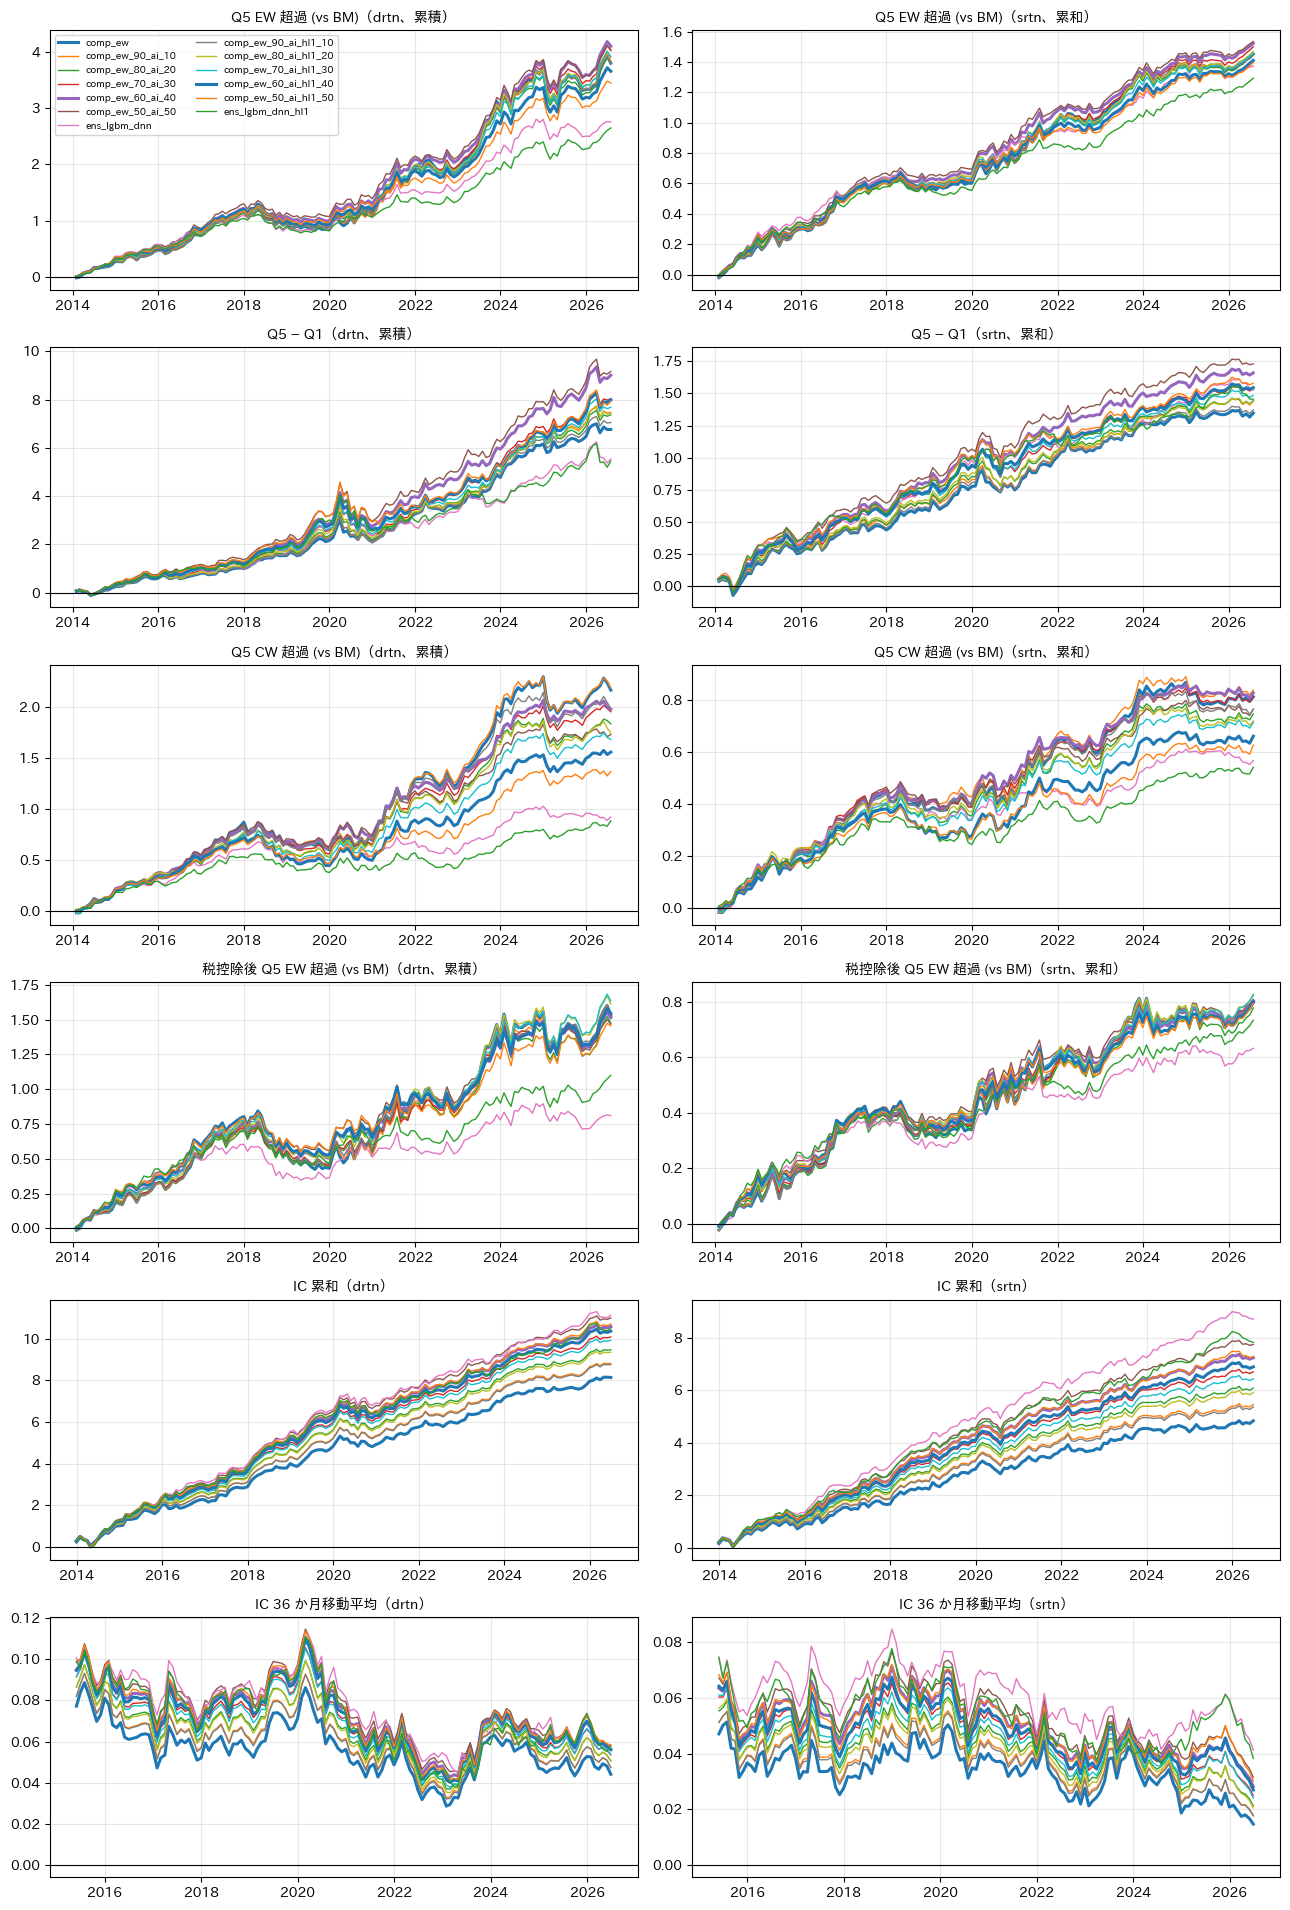

In [5]:
fig = plot_cumulative(reports, highlight=HIGHLIGHT)
plt.show()

## 4. アルファ横断の棒グラフ（年率、IC は平均）

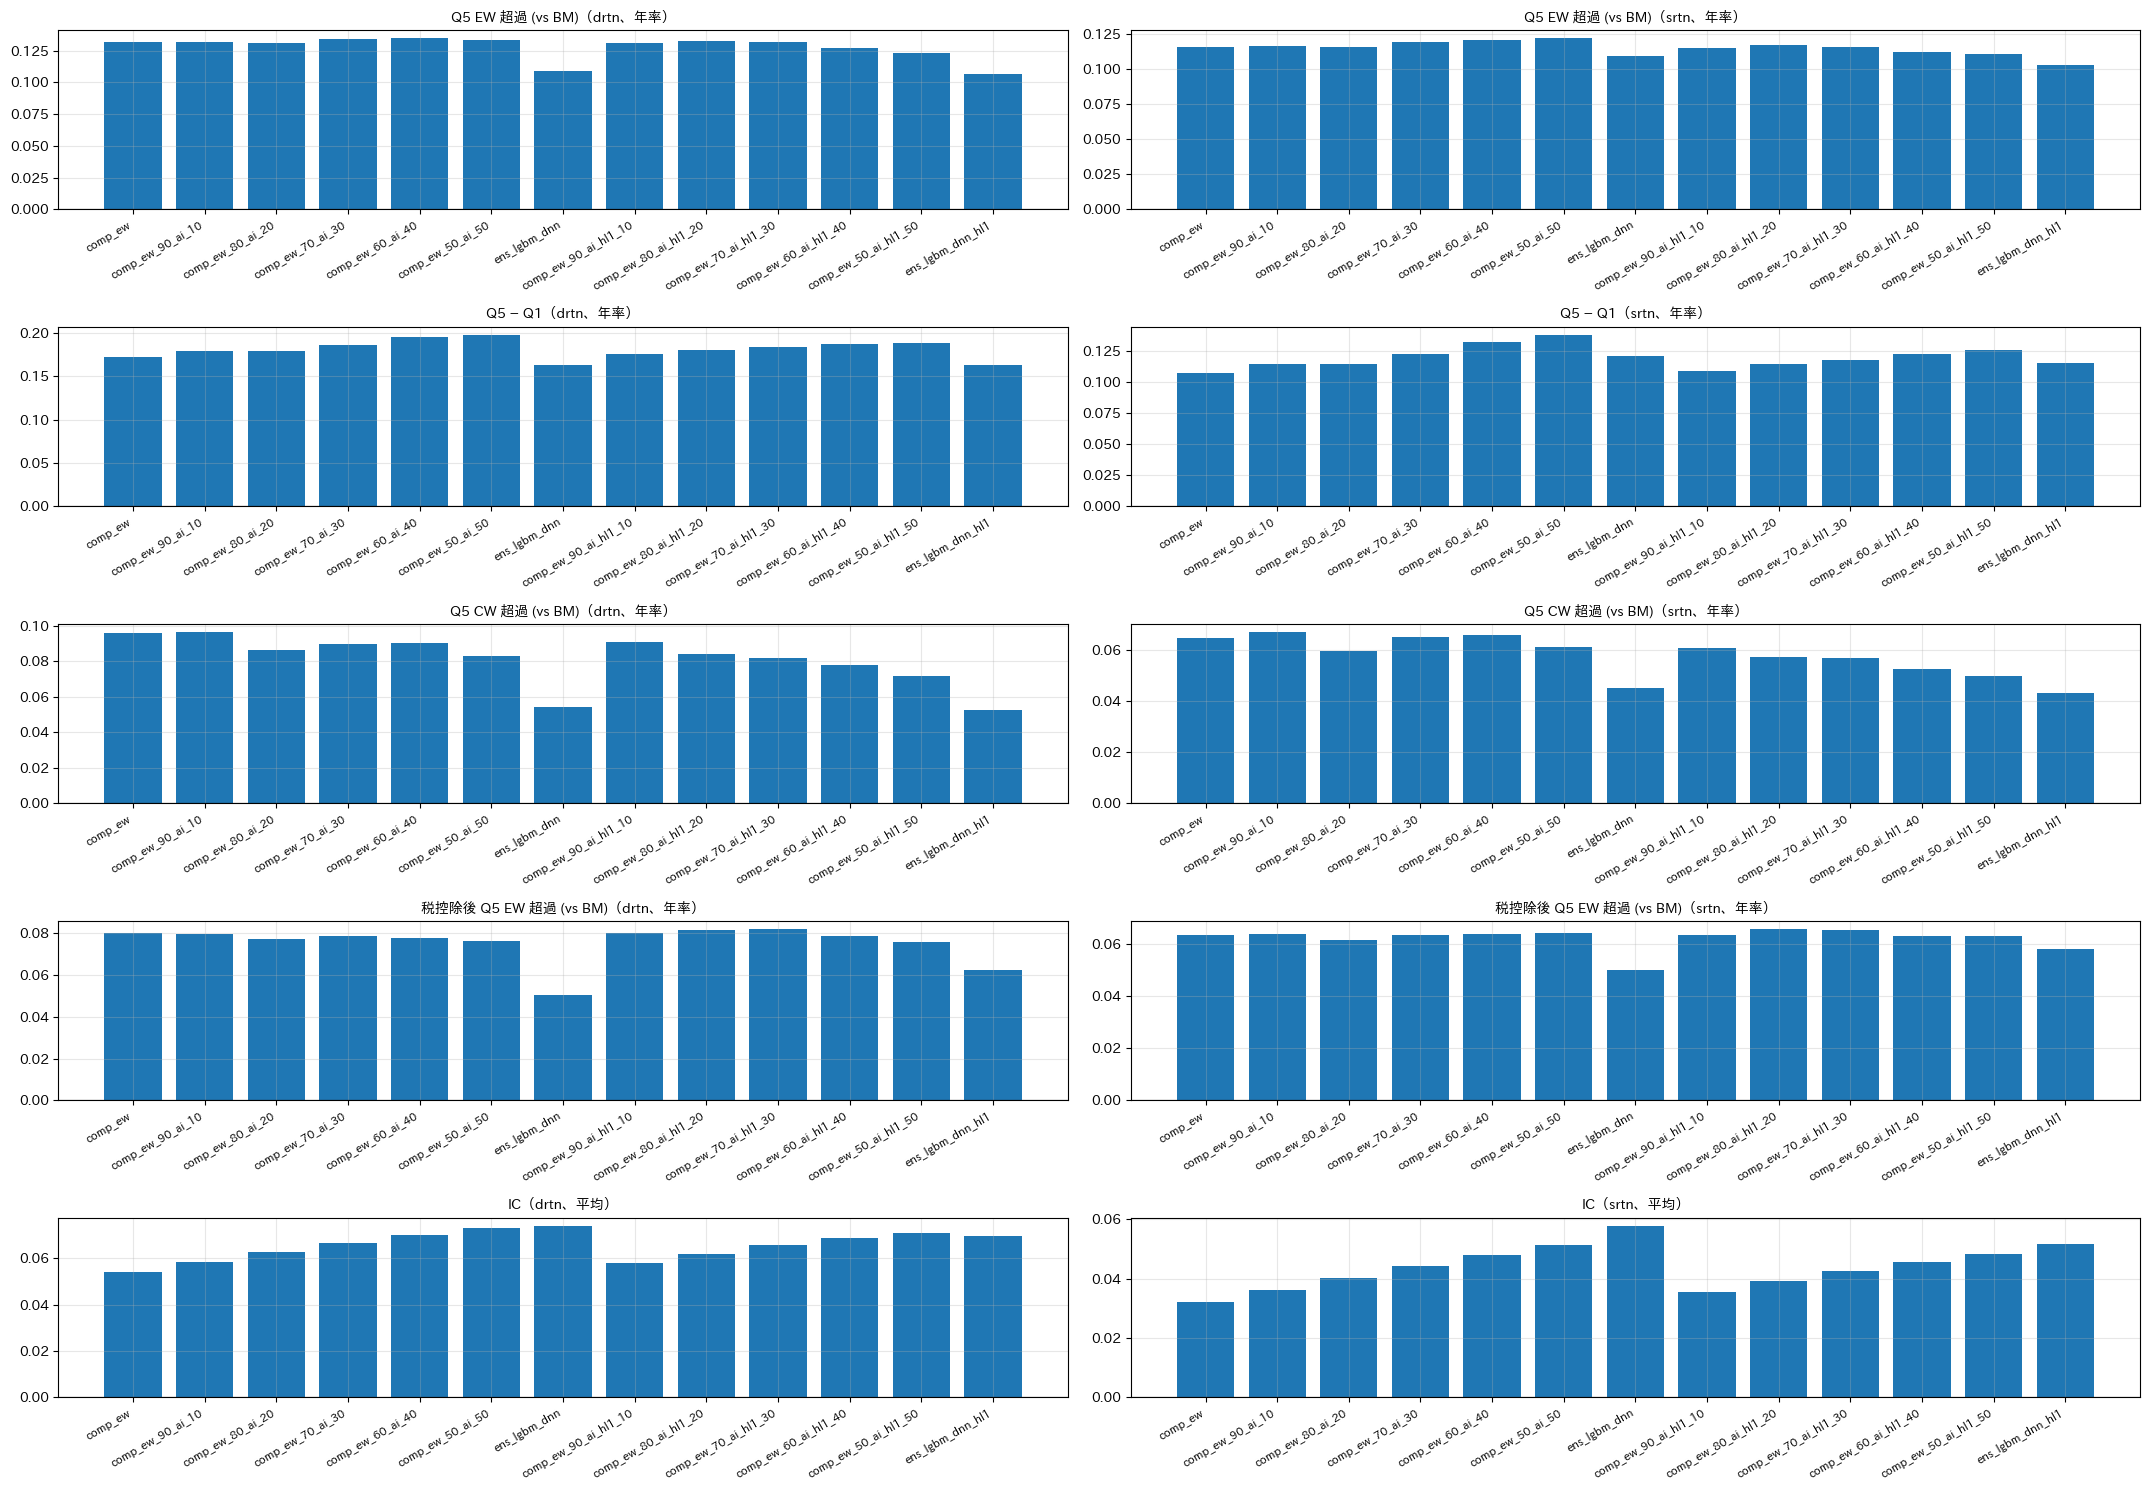

In [6]:
fig = plot_cross_alpha_bars(reports)
plt.show()

## 5. 混合比率と指標（2 系統の比較）

comp_ew の重みを横軸に、Q5 EW 超過（drtn / srtn、年率）、IR、税控除後の超過と IR、回転率を 2 系統で並べる。

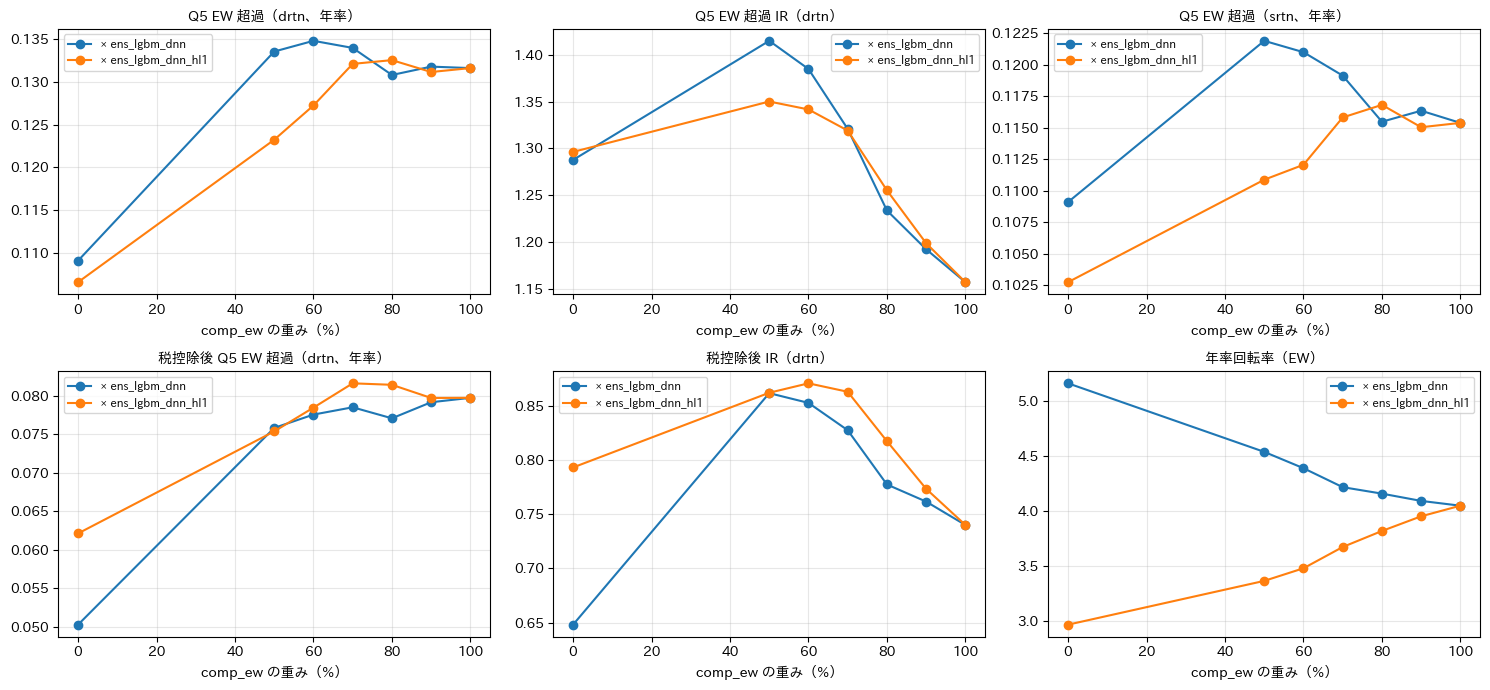

In [7]:
def family(tag: str) -> list[str]:
    return ["comp_ew"] + [f"comp_ew_{w}_{tag}_{100 - w}" for w in W] + [("ens_lgbm_dnn" if tag == "ai" else "ens_lgbm_dnn_hl1")]

W = [90, 80, 70, 60, 50]
xw = [100] + W + [0]
panels = [
    ("drtn", f"{first.top} EW 超過 (vs BM)", "Q5 EW 超過（drtn、年率）"),
    ("drtn", f"{first.top} EW 超過 (vs BM) IR", "Q5 EW 超過 IR（drtn）"),
    ("srtn", f"{first.top} EW 超過 (vs BM)", "Q5 EW 超過（srtn、年率）"),
    ("drtn", f"税控除後 {first.top} EW 超過 (vs BM)", "税控除後 Q5 EW 超過（drtn、年率）"),
    ("drtn", f"税控除後 {first.top} EW 超過 (vs BM) IR", "税控除後 IR（drtn）"),
    ("共通", "回転率 EW", "年率回転率（EW）"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (kind, col, title) in zip(axes.ravel(), panels):
    for tag, label in [("ai", "× ens_lgbm_dnn"), ("ai_hl1", "× ens_lgbm_dnn_hl1")]:
        ax.plot(xw, [tbl.loc[n, (kind, col)] for n in family(tag)], marker="o", label=label)
    ax.set_xlabel("comp_ew の重み（%）")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 所見

評価期間 2014-01〜2026-07、Q5 = 最上位。2 系統（× `ens_lgbm_dnn`、× `ens_lgbm_dnn_hl1`）を comp_ew の重み 100 → 0 で比較。

**Q5 EW 超過（drtn、年率）と IR**

| comp 重み | × ens（超過 / IR） | × ens_hl1（超過 / IR） |
| --- | --- | --- |
| 100 | 13.2% / 1.16 | 同左 |
| 90 | 13.2% / 1.19 | 13.1% / 1.20 |
| 80 | 13.1% / 1.23 | 13.3% / 1.26 |
| 70 | 13.4% / 1.32 | 13.2% / 1.32 |
| 60 | **13.5% / 1.39** | 12.7% / 1.34 |
| 50 | 13.4% / 1.42 | 12.3% / 1.35 |
| 0 | 10.9% / 1.29 | 10.7% / 1.30 |

- 生スコア系統は AI 比率を上げても超過が 13.1〜13.5% で落ちず、TE 低下で IR が 1.16 → 1.42 に上がる。
- 平滑化系統は AI 比率 40% 以上で超過が落ち始める（12.7% → 12.3%）。平滑化で AI の情報が鈍り、合成の便益が小さい。
- srtn でも同じ構図（生系統 11.5% → 12.2%、IR 1.14 → 1.47。平滑化系統は 50:50 で 11.1%）。

**税控除後（drtn）**

| comp 重み | × ens（税後超過 / 税後 IR / 回転率） | × ens_hl1（税後超過 / 税後 IR / 回転率） |
| --- | --- | --- |
| 100 | 8.0% / 0.74 / 405% | 同左 |
| 80 | 7.7% / 0.78 / 416% | **8.1% / 0.82 / 382%** |
| 70 | 7.9% / 0.83 / 422% | **8.2% / 0.86 / 367%** |
| 60 | 7.8% / 0.85 / 439% | 7.8% / 0.87 / 348% |
| 50 | 7.6% / 0.86 / 454% | 7.5% / 0.86 / 336% |

- 税後の超過はどの比率でも 7.5〜8.2% で、親の `comp_ew`（8.0%）とほぼ同じ。合成の便益はリターンではなく **IR（0.74 → 0.86〜0.87）** に出る。
- 回転率は生系統では AI 比率とともに上昇（405% → 454%）、平滑化系統では低下（405% → 336%）。
  税後で見ると平滑化系統の 70〜80% が最良（8.1〜8.2%、IR 0.82〜0.86）で、生系統の同比率（7.7〜7.9%）を上回る。
- Q5 CW 超過（大型株でのキャパシティ）は AI 比率が上がるほど低下し（9.6% → 8.3% / 7.2%）、平滑化系統の方が減衰が大きい。

**判断**

1. グロス（コスト前）で最も良いのは **`comp_ew_60_ai_40`**（超過 13.5%、IR 1.39、Q5−Q1 19.5%）。
2. 税後まで含めると **`comp_ew_70_ai_hl1_30`**（税後 8.2%、税後 IR 0.86、回転率 367%）が最良で、グロス IR 1.32 と 60:40 生系統との差は小さい。
   回転率が 1 割以上低いので、税を主要な評価軸とする本プロジェクトの方針（`docs/india_tcg.md`）ではこちらを採用候補にする。
3. いずれの比率でも `comp_ew` 単体より IR は改善し、超過は落ちない。AI スコアの役割は分散効果によるリスク低減。

**次のステップ**

- `comp_ew_70_ai_hl1_30` と `comp_ew_60_ai_40` を bax の最適化に入力し、制約下（TE 5%、業種 ±3%、個別 ±3%）での実現超過・回転率・税後を `alphaeval.bax` で比較する。
- バッファ付き分位（`evaluate_alpha` の `buffers`）で回転率をさらに下げた場合の税後を確認する。